step    200  t=1.000  rms_dudt=1.476e+01  max|div|=9.18e-06  wall=57.8s  [jacobi]
step    400  t=2.000  rms_dudt=5.410e+00  max|div|=1.09e-05  wall=115.3s  [jacobi]
step    600  t=3.000  rms_dudt=4.157e+00  max|div|=1.08e-05  wall=181.0s  [jacobi]
step    800  t=4.000  rms_dudt=3.240e+00  max|div|=1.00e-05  wall=249.9s  [jacobi]
step   1000  t=5.000  rms_dudt=2.559e+00  max|div|=9.95e-06  wall=319.6s  [jacobi]
step   1200  t=6.000  rms_dudt=2.079e+00  max|div|=1.10e-05  wall=392.2s  [jacobi]
step   1400  t=7.000  rms_dudt=1.717e+00  max|div|=1.12e-05  wall=463.3s  [jacobi]
step   1600  t=8.000  rms_dudt=1.425e+00  max|div|=1.03e-05  wall=537.1s  [jacobi]
step   1800  t=9.000  rms_dudt=1.187e+00  max|div|=1.05e-05  wall=611.2s  [jacobi]
step   2000  t=10.000  rms_dudt=9.944e-01  max|div|=1.04e-05  wall=691.7s  [jacobi]
step   2200  t=11.000  rms_dudt=8.412e-01  max|div|=1.08e-05  wall=783.9s  [jacobi]
step   2400  t=12.000  rms_dudt=7.191e-01  max|div|=1.07e-05  wall=877.4s  [jacobi]
st

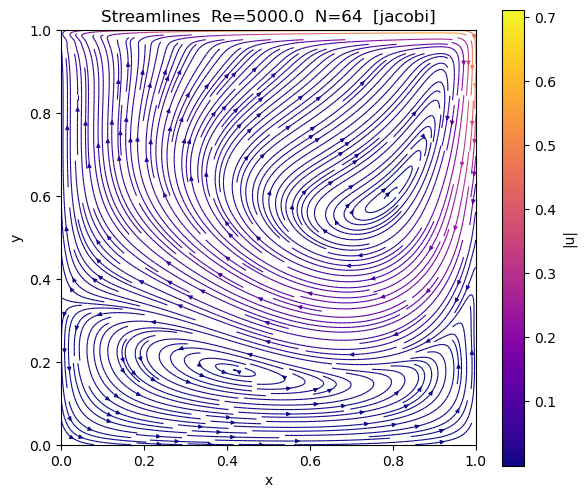

In [1]:
## Shatrov case N = 0.4 for JAX implementation

from cavity_mhd_jax import init, run, plot_streamline

# Hartmann configuration: B = Bo·ex, Re=5000, N=0.4
params, state = init(Re=5000.0, N=64, B=[1, 0, 0], dt=0.005, N_int=0.4, solver='jacobi')

state = run(params, state, t_end=50, steady_tol=1e-3, log_every=200)
plot_streamline(params, state)

All operator tests pass
Cross product tests pass
step    200  t=1.000  rms_dudt=1.476e+01  max|div|=4.76e-10  wall=9.6s
step    400  t=2.000  rms_dudt=5.410e+00  max|div|=4.75e-10  wall=18.4s
step    600  t=3.000  rms_dudt=4.157e+00  max|div|=4.71e-10  wall=27.0s
step    800  t=4.000  rms_dudt=3.240e+00  max|div|=4.71e-10  wall=35.6s
step   1000  t=5.000  rms_dudt=2.559e+00  max|div|=4.84e-10  wall=44.1s
step   1200  t=6.000  rms_dudt=2.079e+00  max|div|=4.73e-10  wall=52.7s
step   1400  t=7.000  rms_dudt=1.717e+00  max|div|=4.71e-10  wall=61.3s
step   1600  t=8.000  rms_dudt=1.425e+00  max|div|=4.76e-10  wall=69.8s
step   1800  t=9.000  rms_dudt=1.187e+00  max|div|=4.82e-10  wall=78.3s
step   2000  t=10.000  rms_dudt=9.944e-01  max|div|=4.88e-10  wall=86.8s
step   2200  t=11.000  rms_dudt=8.412e-01  max|div|=4.92e-10  wall=96.0s
step   2400  t=12.000  rms_dudt=7.191e-01  max|div|=4.95e-10  wall=105.2s
step   2600  t=13.000  rms_dudt=6.211e-01  max|div|=4.96e-10  wall=113.8s
step   280

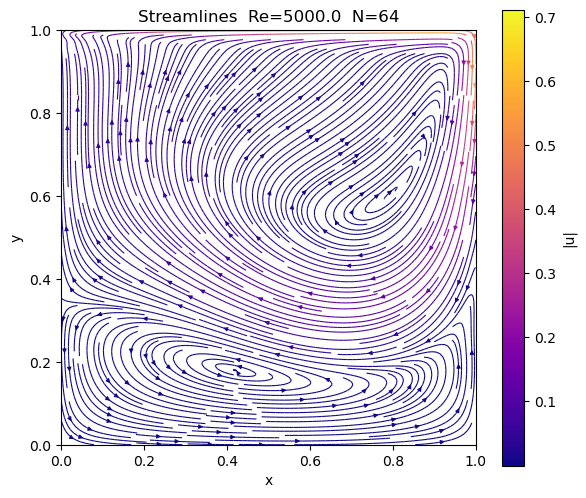

In [2]:
from cavity_mhd_numba import CavityMHD, plot_streamline

sim = CavityMHD(Re=5000.0, N=64, B=[1, 0, 0], dt=0.005, N_int=0.4)
sim.test_operators()
sim.run(t_end=50, steady_tol=1e-3, log_every=200)
plot_streamline(sim.u, sim.v, sim.Re, sim.H, sim.N)